In [1]:

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *
# sys.path = original_sys_path

In [2]:
max_ql = 25
max_ol = 50
system = fluxonium_oscillator_system(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 7.17391479,
    g_strength = 0.14,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.001,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2',
    )



In [3]:
t_stop = 341
tot_time =380
tlist = np.linspace(0, tot_time, tot_time)

results = system.run_mesolve_on_driving_osc(
    intial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i, 0)])) for i in range(3)],
    tlist = tlist,
    osc_decay = False,
    amp = 0.004,
    t_stop = t_stop
)



 Total run time: 4917.86s] Elapsed 4917.86s / Remaining 00:00:00:00
 Total run time: 4951.86s] Elapsed 4951.86s / Remaining 00:00:00:00
 Total run time: 4976.76s] Elapsed 4976.76s / Remaining 00:00:00:00


In [4]:

import pickle
with open('../pickles/sesolve_12_large_dim_2.65_g0.14.pkl', 'wb') as file:
    pickle.dump(results, file)


In [4]:
with open('../pickles/sesolve_12_large_dim_2.65_g0.14.pkl', 'rb') as file:
    results = pickle.load(file)

In [5]:
lists = []
for ql in [0,1,2]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(system.qbt.truncated_dim):
            if q != ql:
                for o in range(system.osc.truncated_dim):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    # print(pop_list)
    lists.append(pop_list)


t loop:   0%|          | 0/380 [00:00<?, ?it/s]

t loop: 100%|██████████| 380/380 [01:10<00:00,  5.40it/s]


In [6]:
with open('../pickles/sesolve_12_large_dim_leakage_list_2.65_g0.14.pkl', 'wb') as file:
    pickle.dump(lists, file)

Text(0.5, 0, 't (ns)')

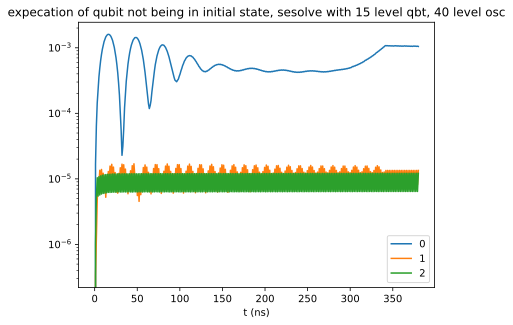

In [7]:
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.title('expecation of qubit not being in initial state, sesolve with 15 level qbt, 40 level osc')
plt.xlabel('t (ns)')

t loop: 100%|██████████| 380/380 [01:13<00:00,  5.19it/s]


Text(0.5, 0, 't (ns)')

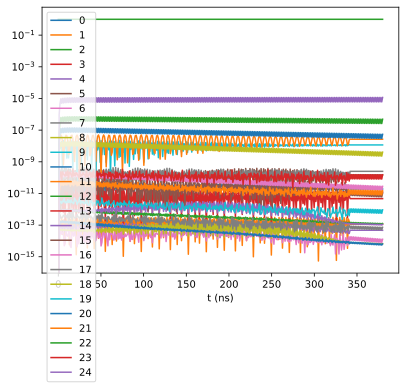

In [8]:
lists = []
for ql in [0,1,2]:
    pops_list = [[] for _ in range(system.qbt.truncated_dim)]
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        for q in range(system.qbt.truncated_dim):
            sum_at_this_t_for_this_q = 0
            for o in range(system.osc.truncated_dim):
                product_state = (q, o)
                dressed_state = system.product_to_dressed[product_state]
                basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                sum_at_this_t_for_this_q += expectation_value
            pops_list[q].append(sum_at_this_t_for_this_q)
    lists.append(pops_list)


for ql,pop_list in enumerate(lists[2][:]): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.xlabel('t (ns)')

In [9]:
with open('../pickles/sesolve_12_large_dim_qubit_pop_list_g0.14.pkl', 'wb') as file:
    pickle.dump(lists, file)

Text(0.5, 0, 't (ns)')

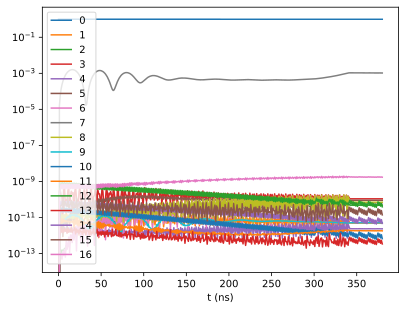

In [10]:

for ql,pop_list in enumerate(lists[0][:17]): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.xlabel('t (ns)')

Text(0.5, 0, 't (ns)')

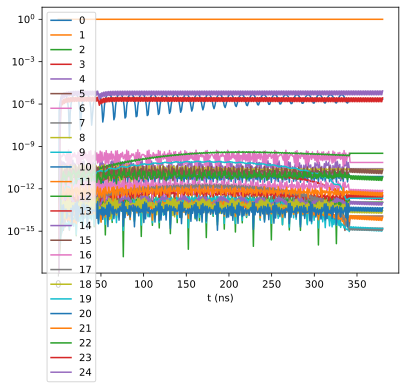

In [11]:

for ql,pop_list in enumerate(lists[1][:]): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.xlabel('t (ns)')

In [5]:
interactive_heatmap(results[0], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=409), Output(…

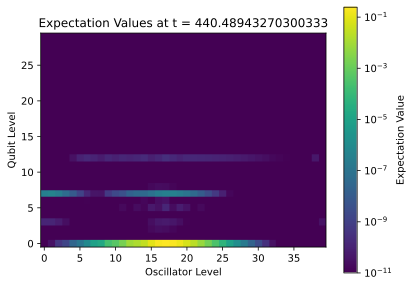

In [26]:
plot_heatmap(results[0], time_index=440, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

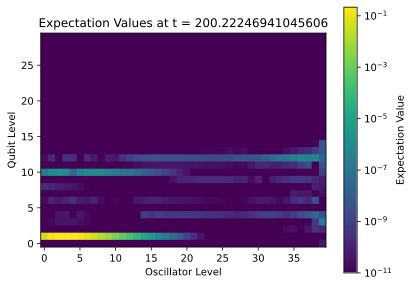

In [27]:
plot_heatmap(results[1], time_index=200, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

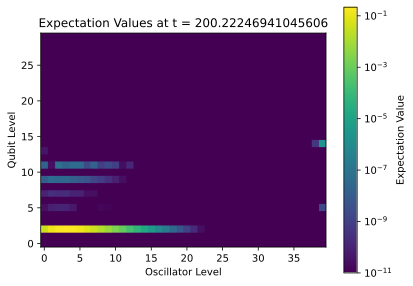

In [28]:
plot_heatmap(results[2], time_index=200, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

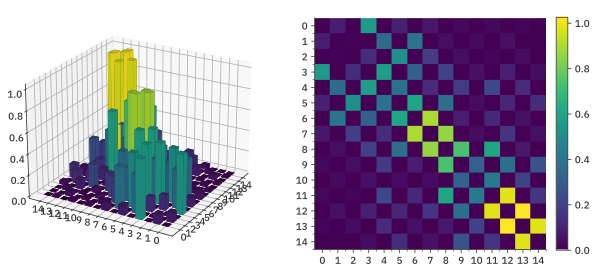

In [29]:
qbt.plot_matrixelements('n_operator',evals_count=15)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

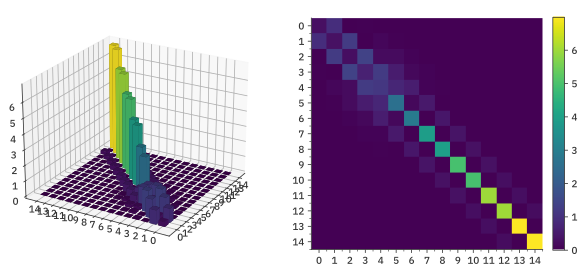

In [30]:
scqubits.Transmon(EJ=30,EC=1.2,ng=0.3,ncut=31).plot_matrixelements('n_operator',evals_count=15)